<a href="https://colab.research.google.com/github/Nandhinimh/DEEPFAKE_DETECTION/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
from keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dropout, Dense,BatchNormalization, Flatten, MaxPooling2D
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,precision_score,recall_score,f1_score,roc_auc_score
from tensorflow.keras.metrics import Precision, Recall, AUC
from keras.layers import Conv2D, Reshape
from keras.utils import Sequence
from keras.backend import epsilon
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tqdm.notebook import tqdm_notebook as tqdm
import os

In [8]:
from google.colab import files
import zipfile, os
uploaded = files.upload()

Saving archive.zip to archive.zip


In [10]:
# Extract uploaded file
for fn in uploaded.keys():
    zip_name = fn

dataset_dir = "/content/deepfake_dataset"
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Dataset extracted successfully at:", dataset_dir)
print("Folders:", os.listdir(dataset_dir))

Dataset extracted successfully at: /content/deepfake_dataset
Folders: ['real_and_fake_face_detection', 'real_and_fake_face']


In [11]:
# Preprocess Dataset
img_size = (128,128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 3266 images belonging to 2 classes.
Found 816 images belonging to 2 classes.


In [12]:
#-------------------CNN---------------------
#MODEL 1: MesoNet
def build_mesoNet():
    model = Sequential([
        Conv2D(8, (3,3), activation='relu', input_shape=(128,128,3)),
        MaxPooling2D(2,2),
        Conv2D(16, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
    )
    return model


# Build & Train the Model

mesonet = build_mesoNet()
history_meso = mesonet.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 39s 356ms/step - accuracy: 0.4896 - auc: 0.4881 - loss: 0.6984 - precision: 0.4787 - recall: 0.4464 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6932 - val_precision: 0.5000 - val_recall: 0.9926
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 38s 367ms/step - accuracy: 0.4994 - auc: 0.4883 - loss: 0.6932 - precision: 0.5029 - recall: 0.8327 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 0.1667
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 38s 369ms/step - accuracy: 0.5070 - auc: 0.4841 - loss: 0.6932 - precision: 0.5176 - recall: 0.8178 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 38s 364ms/step - accuracy: 0.4850 - auc: 0.4898 - loss: 0.6933 - precision: 0.4967 - recall: 0.8528 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 5/10
103/103 ━

In [13]:
# Evaluate Model on Validation Data

val_loss_meso, val_acc_meso, val_prec_meso, val_rec_meso, val_auc_meso = mesonet.evaluate(val_data)

epsilon = 1e-7
val_f1_meso = 2 * (val_prec_meso* val_rec_meso) / (val_prec_meso + val_rec_meso + epsilon)

print("\nPERFORMANCE METRICS (MesoNet)")
print(f"Accuracy: {val_acc_meso*100:.2f}%")
print(f"Precision: {val_prec_meso*100:.2f}%")
print(f"Recall: {val_rec_meso*100:.2f}%")
print(f"F1-Score: {val_f1_meso*100:.2f}%")
print(f"AUC: {val_auc_meso*100:.2f}%")

26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.4859 - auc: 0.5000 - loss: 0.6932 - precision: 0.0000e+00 - recall: 0.0000e+00

PERFORMANCE METRICS (MesoNet)
Accuracy: 50.00%
Precision: 0.00%
Recall: 0.00%
F1-Score: 0.00%
AUC: 50.00%


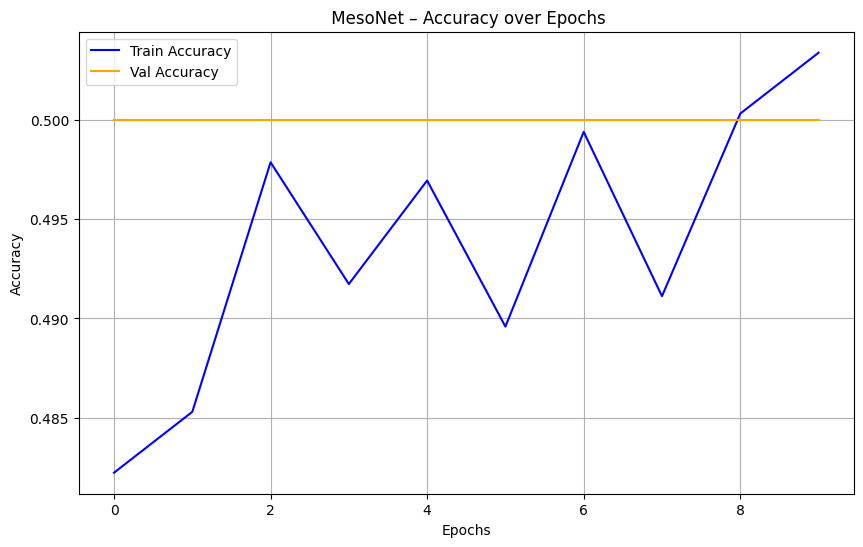

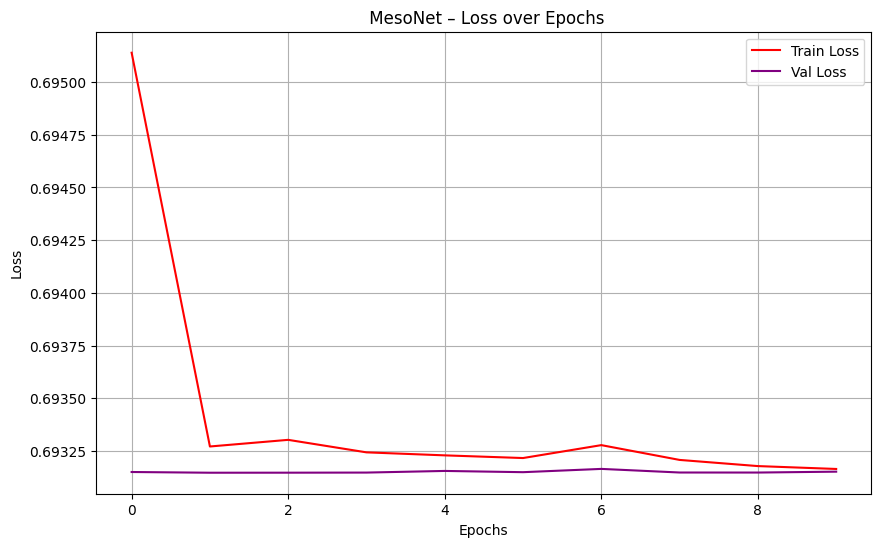

In [14]:
#  Plot Training & Validation Curves

plt.figure(figsize=(10,6))
plt.plot(history_meso.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_meso.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title(' MesoNet – Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(history_meso.history['loss'], label='Train Loss', color='red')
plt.plot(history_meso.history['val_loss'], label='Val Loss', color='purple')
plt.title(' MesoNet – Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
#MODEL 2: MobileNetV2

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  # freeze base layers

mobilenet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

mobilenet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)


# Train the Model

history_mobile = mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 55s 490ms/step - accuracy: 0.5030 - auc: 0.5019 - loss: 0.8341 - precision: 0.5041 - recall: 0.5086 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7581 - val_precision: 0.5000 - val_recall: 0.1103
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 48s 461ms/step - accuracy: 0.4927 - auc: 0.4850 - loss: 0.8133 - precision: 0.4891 - recall: 0.4435 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7323 - val_precision: 0.5000 - val_recall: 0.8554
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 47s 455ms/step - accuracy: 0.4989 - auc: 0.5020 - loss: 0.7709 - precision: 0.4996 - recall: 0.5400 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7090 - val_precision: 0.5000 - val_recall: 0.4828
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 46s 444ms/step - accuracy: 0.4898 - auc: 0.4944 - loss: 0.7498 - precision: 0.4920 - recall: 0.4855 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7204 - val_precision:

In [16]:
# Evaluate Model on Validation Data

val_loss_mob, val_acc_mob, val_prec_mob, val_rec_mob, val_auc_mob = mobilenet.evaluate(val_data)
val_f1_mob = 2 * (val_prec_mob * val_rec_mob) / (val_prec_mob + val_rec_mob)

print("\n PERFORMANCE METRICS (MobileNetV2)")
print(f"Accuracy:  {val_acc_mob*100:.2f}%")
print(f"Precision: {val_prec_mob*100:.2f}%")
print(f"Recall:    {val_rec_mob*100:.2f}%")
print(f"F1-Score:  {val_f1_mob*100:.2f}%")
print(f"AUC:       {val_auc_mob*100:.2f}%")

26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 340ms/step - accuracy: 0.5073 - auc: 0.5202 - loss: 0.7147 - precision: 0.5031 - recall: 0.9483

 PERFORMANCE METRICS (MobileNetV2)
Accuracy:  50.00%
Precision: 50.00%
Recall:    94.36%
F1-Score:  65.37%
AUC:       50.00%


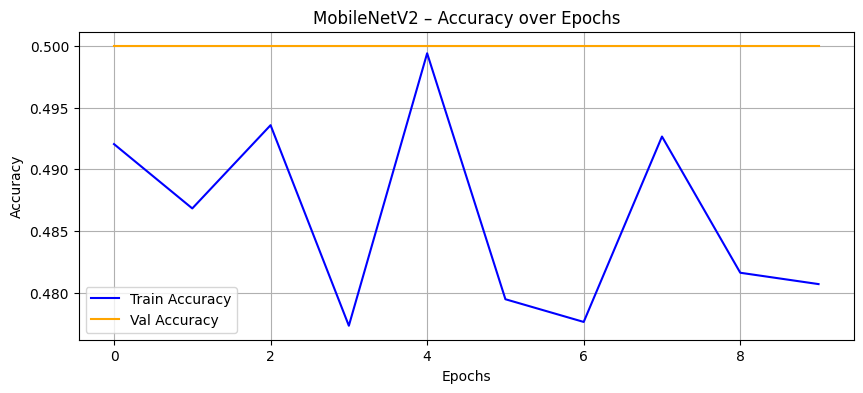

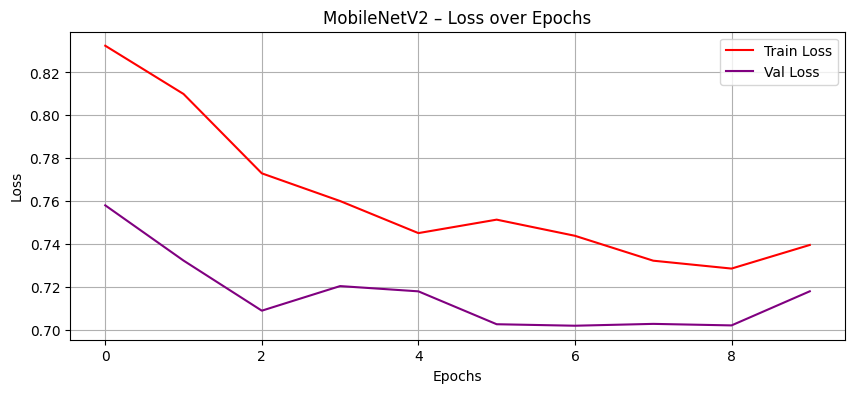

In [20]:
#Plot Training & Validation Accuracy and Loss

plt.figure(figsize=(10,4))
plt.plot(history_mobile.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_mobile.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('MobileNetV2 – Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history_mobile.history['loss'], label='Train Loss', color='red')
plt.plot(history_mobile.history['val_loss'], label='Val Loss', color='purple')
plt.title('MobileNetV2 – Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
#MODEL 3: CNN + SVM Hybrid
# Extract features from MobileNet for SVM

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
feature_extractor = Model(inputs=base_model.input, outputs=GlobalAveragePooling2D()(base_model.output))


#  Extract features from the training set

train_features, train_labels = [], []
for i in range(len(train_data)):
    x_batch, y_batch = train_data[i]
    feats = feature_extractor.predict(x_batch)
    train_features.append(feats)
    train_labels.append(y_batch)
    if i == 10:
        break

X_train = np.concatenate(train_features)
y_train = np.concatenate(train_labels)


#  Extract features from the validation set

val_features, val_labels = [], []
for i in range(len(val_data)):
    x_batch, y_batch = val_data[i]
    feats = feature_extractor.predict(x_batch)
    val_features.append(feats)
    val_labels.append(y_batch)
    if i == 5:
        break

X_val = np.concatenate(val_features)
y_val = np.concatenate(val_labels)


# Train SVM on extracted CNN features

svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train, y_train)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


SVC(kernel='linear', probability=True, random_state=42)

In [22]:
#Evaluate Model
y_pred = svm.predict(X_val)
y_prob = svm.predict_proba(X_val)[:,1]

acc_svm = accuracy_score(y_val, y_pred)
prec_svm = precision_score(y_val, y_pred)
rec_svm = recall_score(y_val, y_pred)
f1_svm = f1_score(y_val, y_pred)
auc_svm = roc_auc_score(y_val, y_prob)

print("\nPERFORMANCE METRICS (CNN + SVM)")
print(f"Accuracy: {acc_svm*100:.2f}%")
print(f"Precision: {prec_svm*100:.2f}%")
print(f"Recall: {rec_svm*100:.2f}%")
print(f"F1-Score: {f1_svm*100:.2f}%")
print(f"AUC: {auc_svm*100:.2f}%")


PERFORMANCE METRICS (CNN + SVM)
Accuracy: 50.00%
Precision: 50.86%
Recall: 60.20%
F1-Score: 55.14%
AUC: 54.80%


In [23]:
# model evaluation sections

meso_metrics = {'accuracy': val_acc_meso, 'precision': val_prec_meso, 'recall': val_rec_meso, 'f1': val_f1_meso, 'auc': val_auc_meso}
mobile_metrics = {'accuracy': val_acc_mob, 'precision': val_prec_mob, 'recall': val_rec_mob, 'f1': val_f1_mob, 'auc': val_auc_mob}
svm_metrics = {'accuracy': acc_svm, 'precision': prec_svm, 'recall': rec_svm, 'f1': f1_svm, 'auc': auc_svm}


MODEL PERFORMANCE SUMMARY


,accuracy,precision,recall,f1,auc
MesoNet,0.5,0.000000,0.000000,0.000000,0.500000
MobileNetV2,0.5,0.500000,0.943627,0.653650,0.500000
CNN + SVM,0.5,0.508621,0.602041,0.551402,0.548035


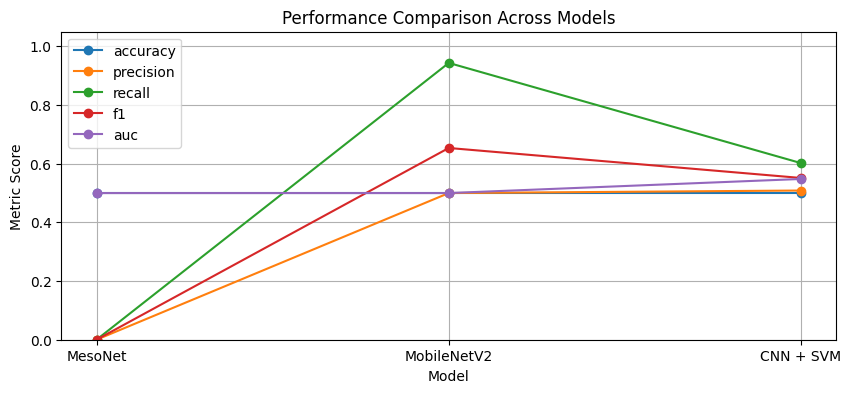

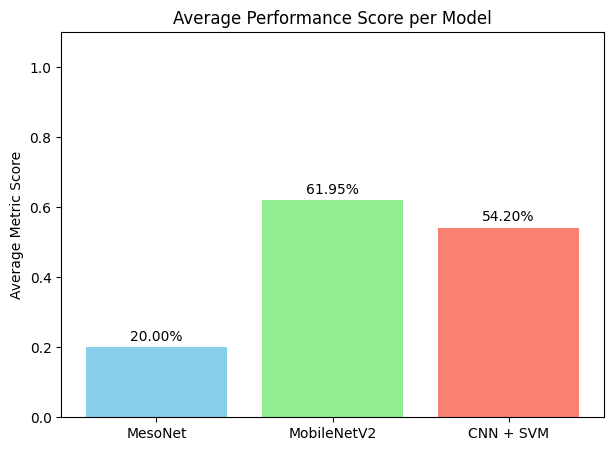

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


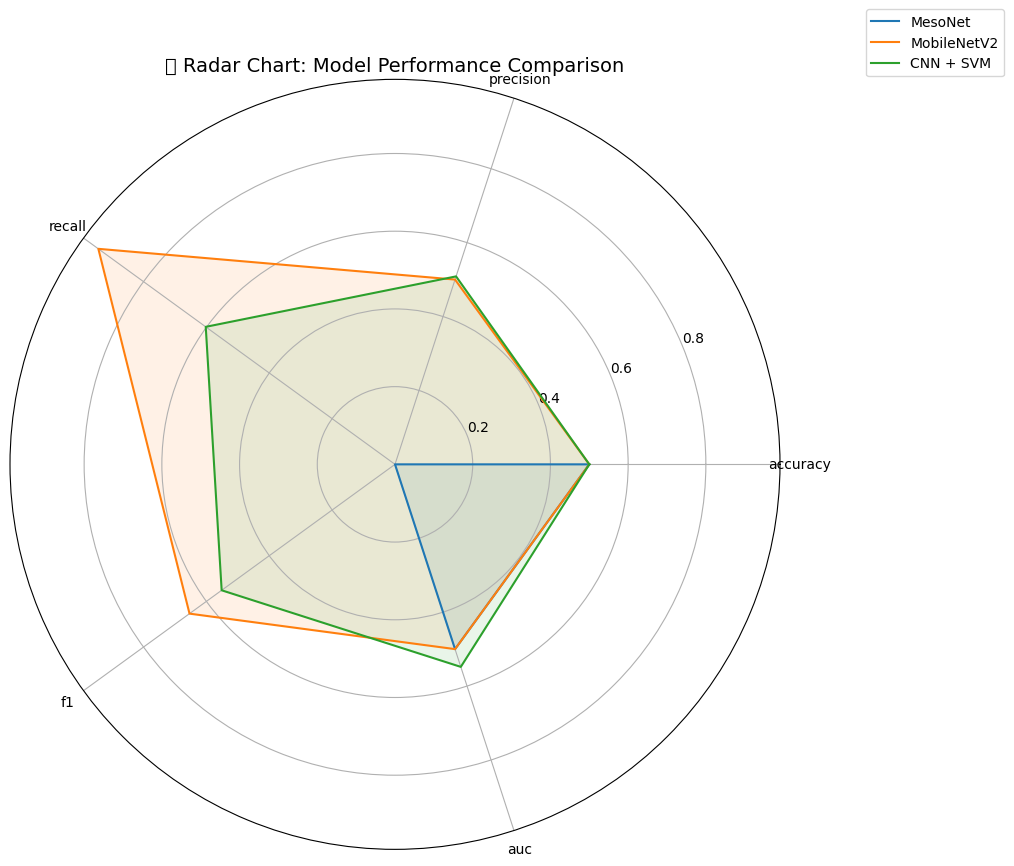

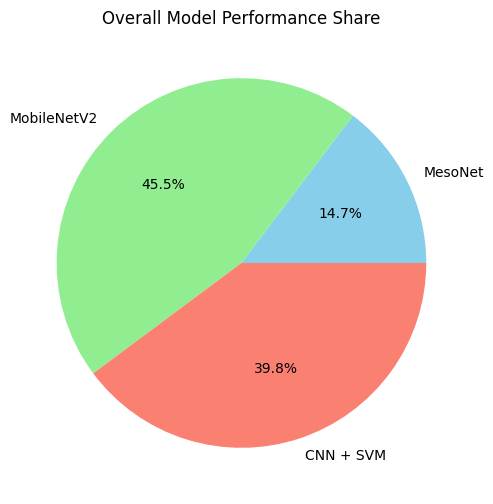

FINAL COMPARISON REPORT
──────────────────────────────
MesoNet: Accuracy=0.500, Precision=0.000, Recall=0.000, F1=0.000, AUC=0.500
MobileNetV2: Accuracy=0.500, Precision=0.500, Recall=0.944, F1=0.654, AUC=0.500
CNN + SVM: Accuracy=0.500, Precision=0.509, Recall=0.602, F1=0.551, AUC=0.548

Best Performing Model Based on Overall Average Score: MobileNetV2


In [29]:
#Combine and Visualize Results
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Combine all metrics into a DataFrame
results_df = pd.DataFrame({
    'MesoNet': meso_metrics,
    'MobileNetV2': mobile_metrics,
    'CNN + SVM': svm_metrics
}).T

print("\nMODEL PERFORMANCE SUMMARY")
display(results_df)


# 1.LINE CHART - Metric Trends Across Models

plt.figure(figsize=(10,4))
for metric in results_df.columns:
    plt.plot(results_df.index, results_df[metric], marker='o', label=metric)
plt.title("Performance Comparison Across Models")
plt.ylabel("Metric Score")
plt.xlabel("Model")
plt.ylim(0,1.05)
plt.legend()
plt.grid(True)
plt.show()


# 2.BAR CHART – Average Performance per Model

avg_scores = results_df.mean(axis=1)
plt.figure(figsize=(7,5))
bars = plt.bar(results_df.index, avg_scores, color=['skyblue','lightgreen','salmon'])
plt.title("Average Performance Score per Model")
plt.ylabel("Average Metric Score")

for bar, score in zip(bars, avg_scores):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{score*100:.2f}%", ha='center', va='bottom')

plt.ylim(0,1.1)
plt.show()


# 3.RADAR CHART – Metric Profile per Model

from math import pi

metrics = list(results_df.columns)
N = len(metrics)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)

for model in results_df.index:
    values = results_df.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
plt.title("🕸️ Radar Chart: Model Performance Comparison", size=14)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


# 4.PIE CHART – Contribution of Each Model to Overall Performance

total_perf = avg_scores / avg_scores.sum()
plt.figure(figsize=(6,6))
plt.pie(total_perf, labels=avg_scores.index, autopct='%1.1f%%', colors=['skyblue','lightgreen','salmon'])
plt.title("Overall Model Performance Share")
plt.show()


# 5. FINAL CONCLUSION REPORT

best_model = avg_scores.idxmax()
print("FINAL COMPARISON REPORT")
print("──────────────────────────────")
for model in results_df.index:
    print(f"{model}: Accuracy={results_df.loc[model,'accuracy']:.3f}, Precision={results_df.loc[model,'precision']:.3f}, Recall={results_df.loc[model,'recall']:.3f}, F1={results_df.loc[model,'f1']:.3f}, AUC={results_df.loc[model,'auc']:.3f}")

print("\nBest Performing Model Based on Overall Average Score:", best_model)
